# CELL 1: IMPORTING LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)

# CELL 2: LOADING DATASET AND SAMPLE CREATION

In [4]:
from google.colab import files
uploaded = files.upload()

df= pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("--- Dataset Shape ---")
print(df.shape)

print(df.info())

print("\n--- Descriptive Statistics ---")
print(df.describe())


print("\n--- DatA Types---")
print(df.dtypes)

print("\n--- Sample Data ---")
df.head()

pd.isnull(df).sum()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
--- Dataset Shape ---
(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# CELL 3: DATA CLEANING AND INTERGRATION

In [5]:
# 1. Imputation of TotalCharges for New Customers
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Logic: If tenure is 0, TotalCharges must be 0 (billed at end of month)
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)


# Standardize "No internet service" and "No phone service" to a simple "No"
# to allow direct comparison of yes or no
integration_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

for col in integration_cols:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Drop the column customerid
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Convert SeniorCitizen to a readable Category for the EDA
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})


if df['SeniorCitizen'].dtype != 'O':
    df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print("DAT CLEANING AND INTERGRATION")
print(f"Nulls in TotalCharges: {df['TotalCharges'].isnull().sum()}")
print(f"Unique values in OnlineSecurity: {df['OnlineSecurity'].unique()}")
print("\nData cleaning and intergration completed successfully")

DAT CLEANING AND INTERGRATION
Nulls in TotalCharges: 0
Unique values in OnlineSecurity: ['No' 'Yes']

Data cleaning and intergration completed successfully


# CELL 4: EXPLORATORY DATA ANALYSIS

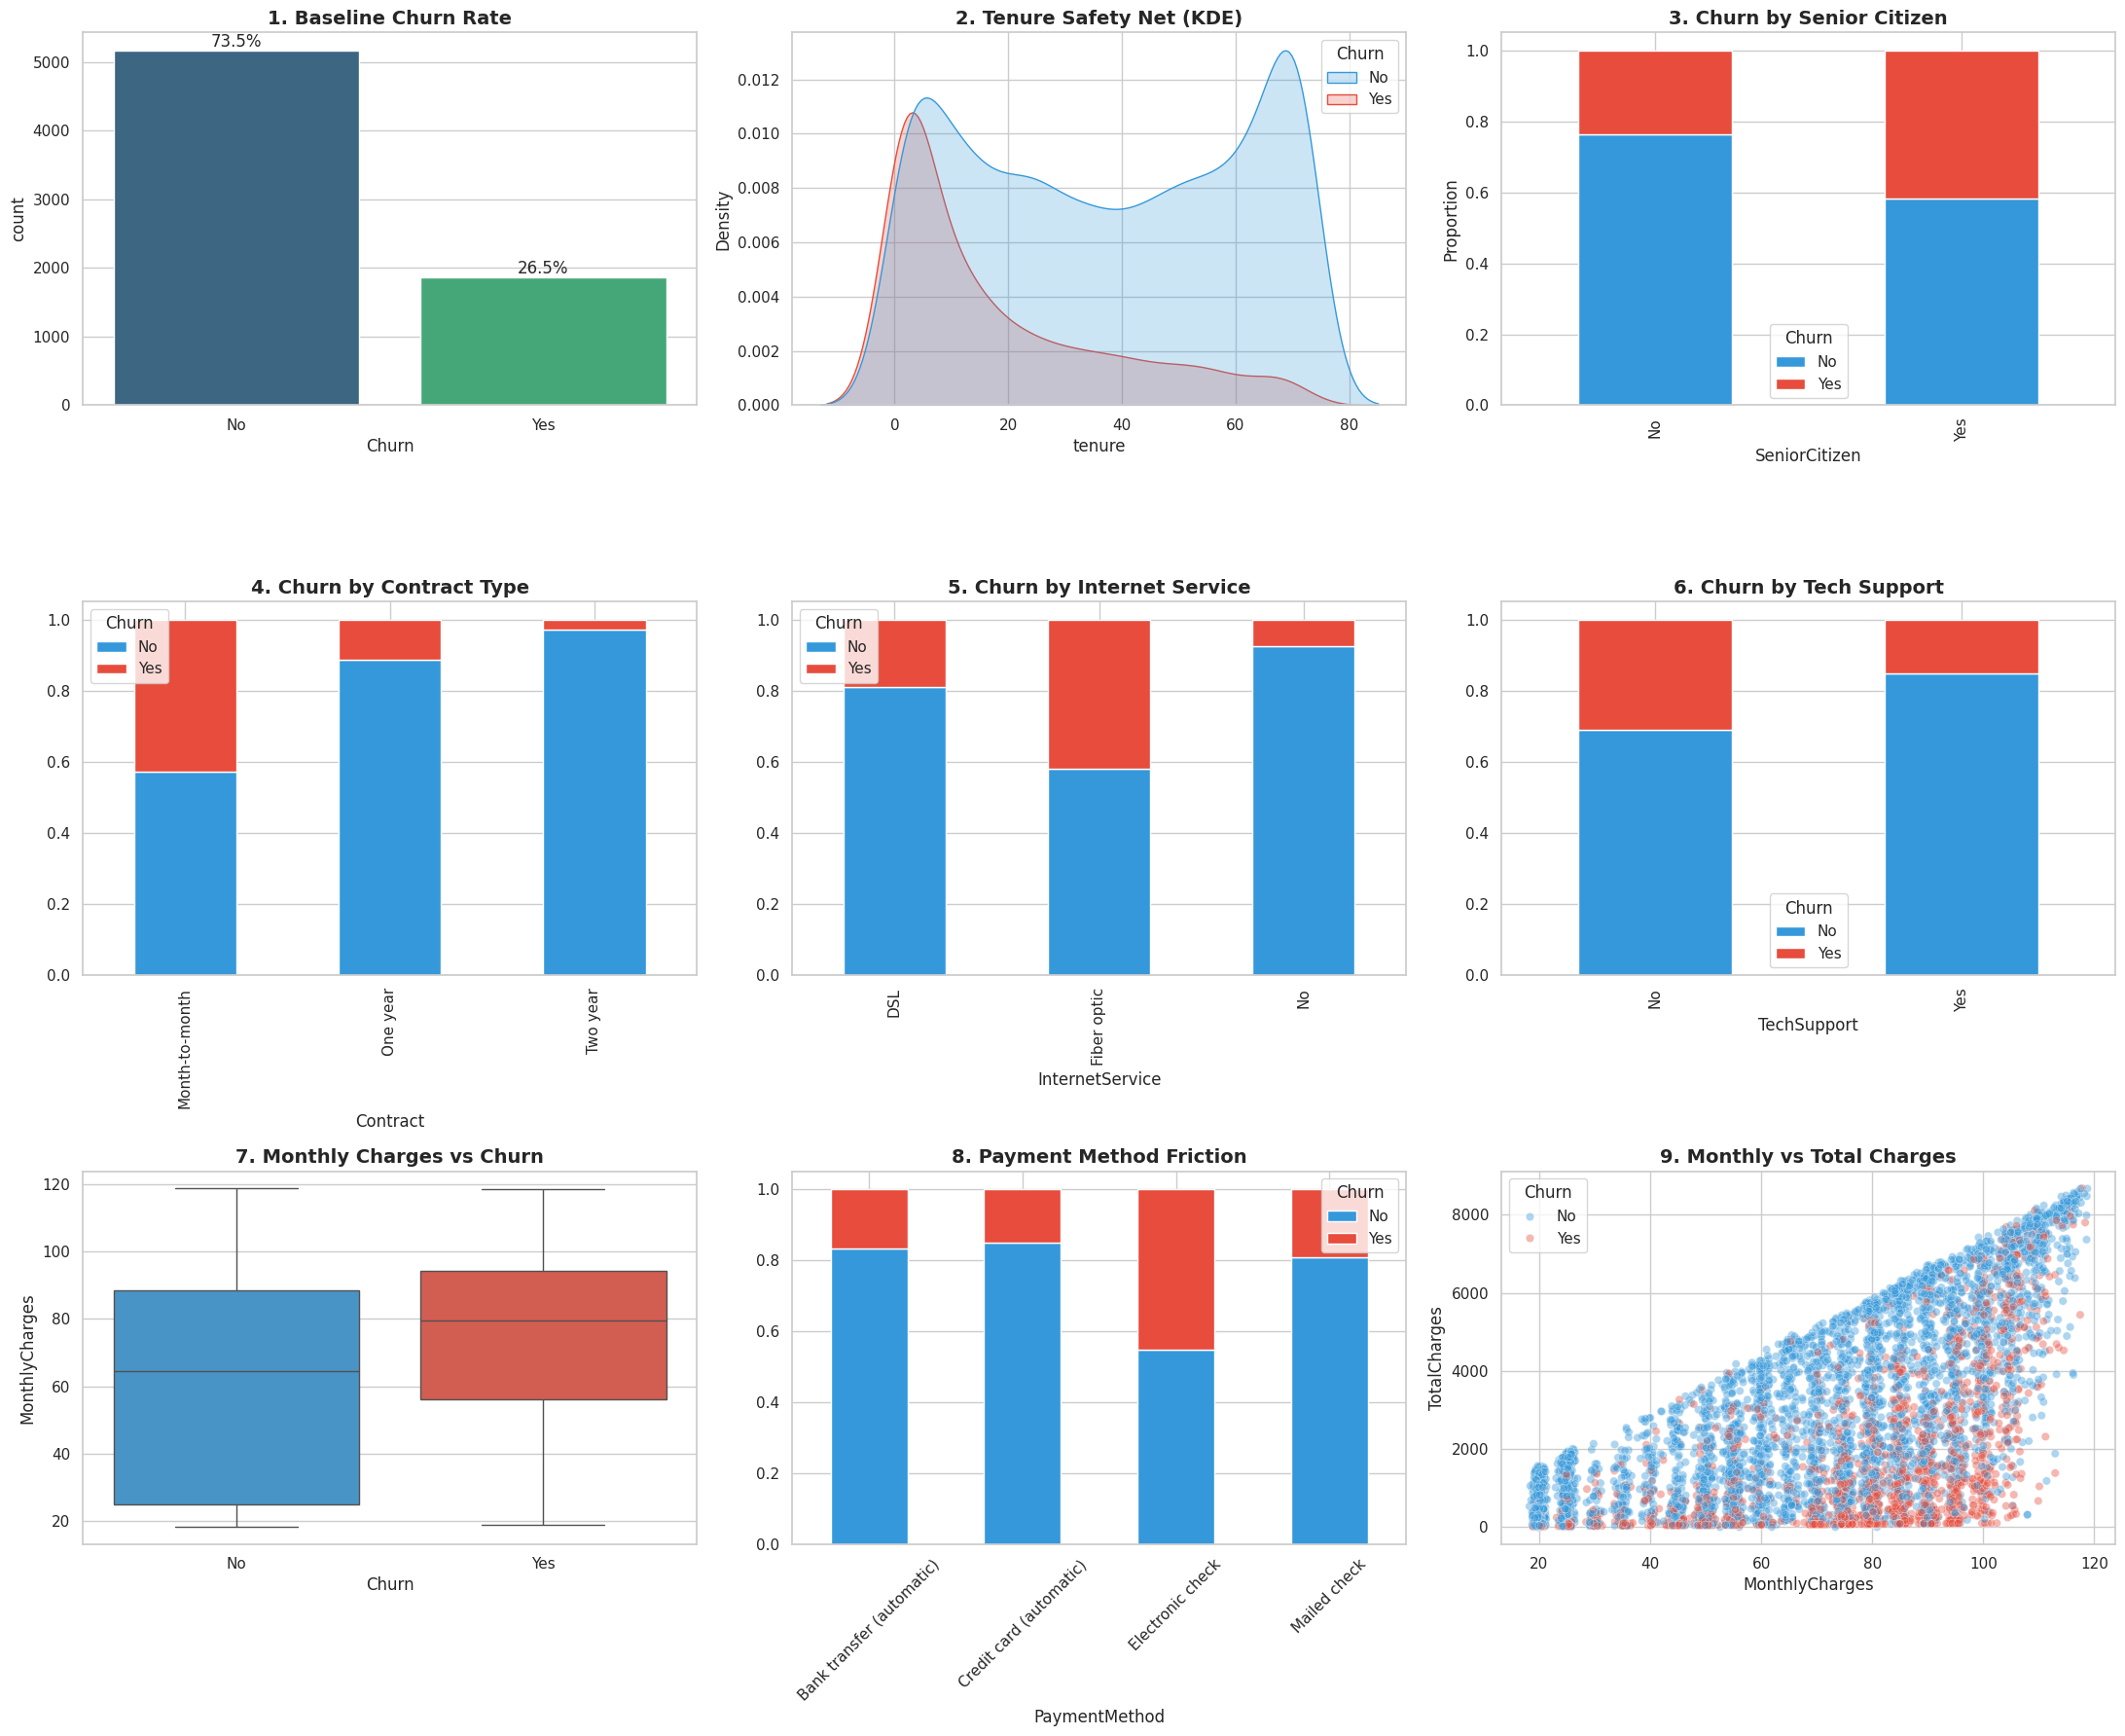

In [6]:

# ROBUST MAPPING: Only map if the column is still numeric to avoid NaN errors
if df['SeniorCitizen'].dtype != 'O':
    df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# --- STEP 2: GENERATE 3x3 MATRIX ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Baseline Churn Rate (Fixes palette warning)
sns.countplot(x='Churn', data=df, ax=axes[0, 0], hue='Churn', palette='viridis', legend=False)
axes[0, 0].set_title('1. Baseline Churn Rate', fontsize=14, fontweight='bold')
total = len(df)
for p in axes[0, 0].patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    axes[0, 0].annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom')

# 2. Tenure Safety Net (KDE)
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, palette=['#3498db', '#e74c3c'], ax=axes[0, 1])
axes[0, 1].set_title('2. Tenure Safety Net (KDE)', fontsize=14, fontweight='bold')

# 3. Senior Citizen Impact (FIXED: Uses crosstab for numeric plotting)
ct3 = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index')
ct3.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], ax=axes[0, 2])
axes[0, 2].set_title('3. Churn by Senior Citizen', fontsize=14, fontweight='bold')
axes[0, 2].set_ylabel('Proportion')

# 4. Contract Influence
ct4 = pd.crosstab(df['Contract'], df['Churn'], normalize='index')
ct4.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], ax=axes[1, 0])
axes[1, 0].set_title('4. Churn by Contract Type', fontsize=14, fontweight='bold')

# 5. Internet Service Patterns
ct5 = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')
ct5.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], ax=axes[1, 1])
axes[1, 1].set_title('5. Churn by Internet Service', fontsize=14, fontweight='bold')

# 6. TechSupport "Stickiness"
ct6 = pd.crosstab(df['TechSupport'], df['Churn'], normalize='index')
ct6.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], ax=axes[1, 2])
axes[1, 2].set_title('6. Churn by Tech Support', fontsize=14, fontweight='bold')

# 7. Monthly Charges Threshold
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[2, 0], hue='Churn', palette=['#3498db', '#e74c3c'], legend=False)
axes[2, 0].set_title('7. Monthly Charges vs Churn', fontsize=14, fontweight='bold')

# 8. Payment Method Friction
ct8 = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')
ct8.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], ax=axes[2, 1])
axes[2, 1].set_title('8. Payment Method Friction', fontsize=14, fontweight='bold')
axes[2, 1].tick_params(axis='x', rotation=45)

# 9. Monthly vs Total Charges (Scatter)
sns.scatterplot(x='MonthlyCharges', y='TotalCharges', hue='Churn', data=df, ax=axes[2, 2], alpha=0.4, palette=['#3498db', '#e74c3c'])
axes[2, 2].set_title('9. Monthly vs Total Charges', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# CELL 5: REPORT GENERATION

In [7]:

# Metrics for the Report
total_cust = len(df)
churn_yes = df[df['Churn'] == 'Yes'].shape[0]
churn_no = df[df['Churn'] == 'No'].shape[0]
churn_pct = (churn_yes / total_cust) * 100

# 1. Contract Analysis (Counts)
contract_counts = df.groupby(['Contract', 'Churn']).size().unstack()

# 2. Senior Citizen Analysis (Counts)
senior_counts = df.groupby(['SeniorCitizen', 'Churn']).size().unstack()

# 3. Financial Thresholds
avg_monthly_churn = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()
max_monthly_churn = df[df['Churn'] == 'Yes']['MonthlyCharges'].max()

# --- REPORT OUTPUT ---
print("="*60)
print("TELCO CHURN STRATEGIC REPORT")
print("="*60)

print(f"\n[SECTION 1: BASELINE SCOPE]")
print(f"Total Customer Base: {total_cust} accounts")
print(f"Customers Lost (Churn=Yes): {churn_yes} accounts")
print(f"Customers Retained (Churn=No): {churn_no} accounts")
print(f"Baseline Churn Rate: {churn_pct:.2f}%")

print(f"\n[SECTION 2: CONTRACTUAL VOLUME]")
print("Breakdown of Churn by Contract Type (Raw Counts):")
print(contract_counts)
print(f"Observation: Month-to-month contracts account for {contract_counts.loc['Month-to-month', 'Yes']} of all lost customers.")

print(f"\n[SECTION 3: SERVICE & DEMOGRAPHIC RISK]")
print(f"Senior Citizen Churn Volume:")
print(senior_counts)
print(f"Fiber Optic Churn Volume: {len(df[(df['InternetService']=='Fiber optic') & (df['Churn']=='Yes')])} accounts")

print(f"\n[SECTION 4: FINANCIAL BENCHMARKS]")
print(f"Average Monthly Bill of Churned Users: ${avg_monthly_churn:.2f}")
print(f"Highest Monthly Bill among Churned Users: ${max_monthly_churn:.2f}")
print("="*60)

TELCO CHURN STRATEGIC REPORT

[SECTION 1: BASELINE SCOPE]
Total Customer Base: 7043 accounts
Customers Lost (Churn=Yes): 1869 accounts
Customers Retained (Churn=No): 5174 accounts
Baseline Churn Rate: 26.54%

[SECTION 2: CONTRACTUAL VOLUME]
Breakdown of Churn by Contract Type (Raw Counts):
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48
Observation: Month-to-month contracts account for 1655 of all lost customers.

[SECTION 3: SERVICE & DEMOGRAPHIC RISK]
Senior Citizen Churn Volume:
Churn            No   Yes
SeniorCitizen            
No             4508  1393
Yes             666   476
Fiber Optic Churn Volume: 1297 accounts

[SECTION 4: FINANCIAL BENCHMARKS]
Average Monthly Bill of Churned Users: $74.44
Highest Monthly Bill among Churned Users: $118.35



**1. Churn Magnitude and the "Early Tenure Crisis"**
*   **Baseline Churn Rate:** The overall churn rate for the company is **26.5%**, indicating that approximately one in four customers eventually leaves the service.
*   **Tenure Safety Net:** The KDE plot reveals an **"early-tenure crisis."** Churn is heavily front-loaded, with a massive peak in departures occurring within the **first 10 months**. Conversely, customers who reach a tenure of **60 to 70 months** are significantly less likely to churn, forming a stable "loyalty peak".

**2. Contractual and Service Volatility**
*   **Contract Type:** This is one of the strongest predictors of retention. **Month-to-month contracts** have a disproportionately high churn proportion, whereas **Two-year contracts** show almost negligible attrition. Commitments act as a critical "retention anchor".
*   **Internet Service Impact:** Customers with **Fiber optic** service are far more likely to leave than those on DSL or those with no internet service. This suggests high-value users may be facing service issues or are being targeted more aggressively by competitors.
*   **The "Sticky" Service Benefit:** Subscribing to **Tech Support** significantly reduces the likelihood of churn. Customers who do *not* have Tech Support show a much higher proportion of departures.

**3. Financial Drivers of Churn**
*   **The "Price Pinch":** There is a clear correlation between cost and churn. The median **Monthly Charge** for customers who leave is approximately **$80**, which is significantly higher than the median of roughly **$65** for those who stay.
*   **Total vs. Monthly Charges:** The scatterplot shows that while many customers accumulate high **Total Charges** over time, a large cluster of churners is concentrated in the **high MonthlyCharges** range (above $70), confirming that expensive monthly bills drive customers away regardless of their total lifetime spend.

 **4. Demographic and Behavioral Friction**
*   **Senior Citizen Vulnerability:** **Senior citizens** have a higher proportion of churn compared to non-seniors. This segment may require more focused support or tailored billing plans to increase loyalty.
*   **Payment Method Friction:** The **Electronic check** method is associated with the highest churn proportion by far. Automatic methods like **Bank transfer** and **Credit card** are linked to much higher retention rates, suggesting that manual payment processes might be a point of friction for customers.

**5. Data Quality and New Customers**
*   customers with **tenure 0** have blank strings for **TotalCharges**. These are brand-new customers who have just joined and haven't yet completed a billing cycle, and they fall into the highest-risk category for early churn as seen in the KDE tenure plot.


Baseline churn rate is 26.5%

The most critical drivers of this behaviour are:

Tenure: New customers are at the highest risk, particularly in the first 10 months

Contract Type: Customers on Month-to-month contracts are significantly more likely to leave than those on long-term commitments

Financials: High-paying customers show a higher proportion of churn compared to those paying less

Internet Service: Customers with Fiber optic service have a disproportionately high attrition rate


# CELL 6: CUSTOMER CHURN PREDICTION MODEL

                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Model                                                                 
Logistic Regression  0.806955   0.659375  0.564171  0.608069  0.841923
Gradient Boosting    0.797729   0.653979  0.505348  0.570136  0.841481
Random Forest        0.795600   0.647260  0.505348  0.567568  0.825752


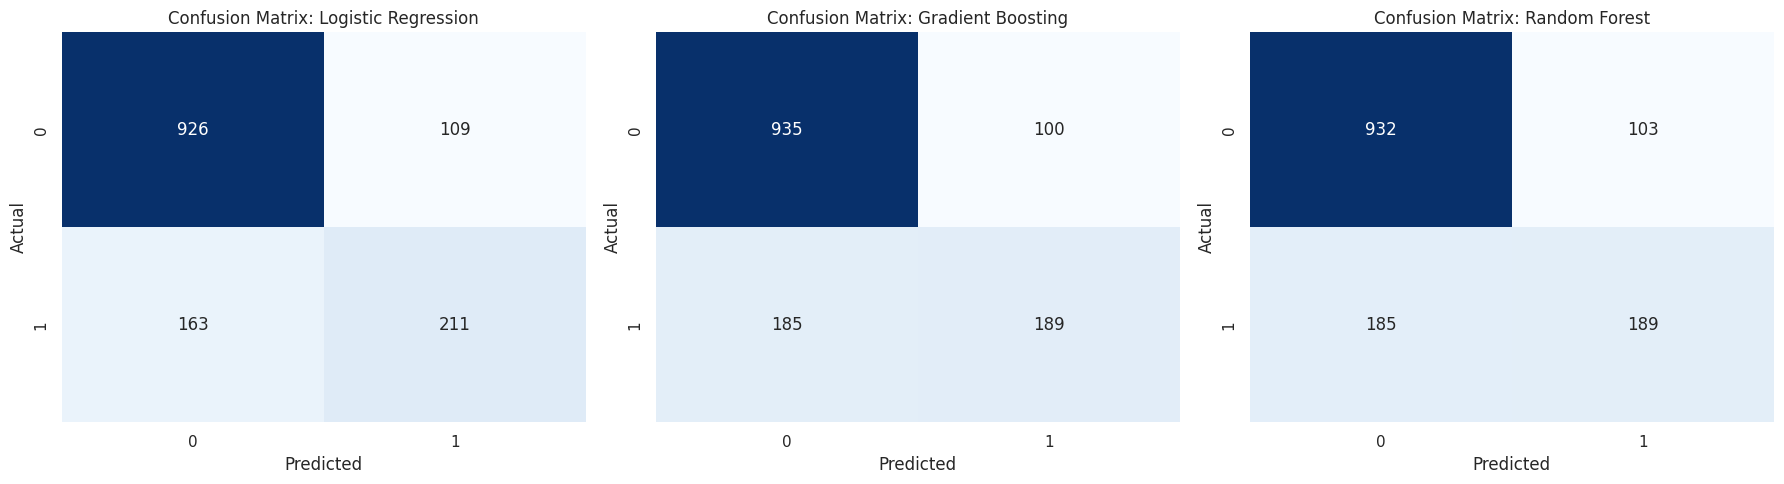

In [20]:
# Features (X) and Target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

X = pd.get_dummies(X, drop_first=True)
y = df['Churn'].map({'No': 0, 'Yes': 1})

# 4. Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# 7. Comprehensive Evaluation
results = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    # Fit
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
    results.append(metrics)

    # Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png')

# Display Table
results_df = pd.DataFrame(results).set_index('Model')
print(results_df)

# CELL 7:Performance Analysis

Logistic Regression model is the best-performing algorithm for this project.

Accuracy (80.70%): It predicts the correct outcome (Stayed or Churned) more often than the other models.

Recall (56.42%):It means this model caught roughly 6% more actual churners than the Gradient Boosting and Random Forest models (which both caught only 50.5%).

F1-Score (0.608): This is the best overall indicator. It proves that Logistic Regression provides the best balance between being correct when it predicts churn and actually finding the churners.

ROC-AUC (0.842): This indicates excellent "Separation Power." It means the model is highly effective at distinguishing between a loyal customer and a high-risk one.

In [13]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')